The following cell lets you visaulize some random heatmaps among the indices (time instances) selected as valid pos samples.
The code access only to Scenario 17 (for simplicity).

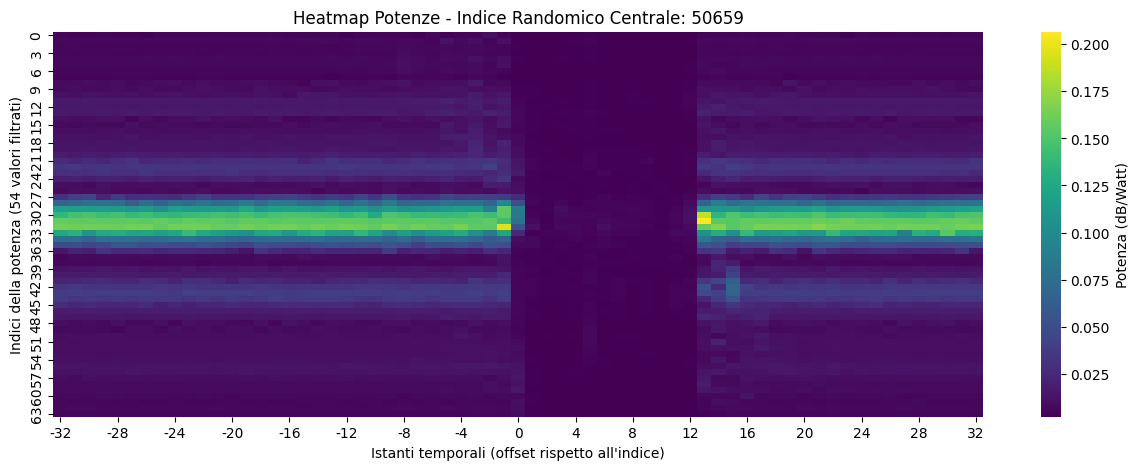

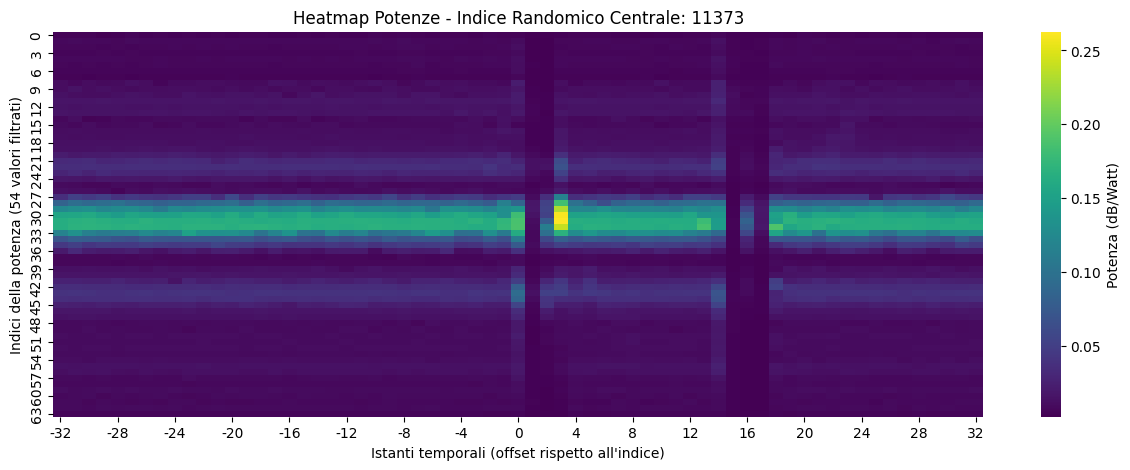

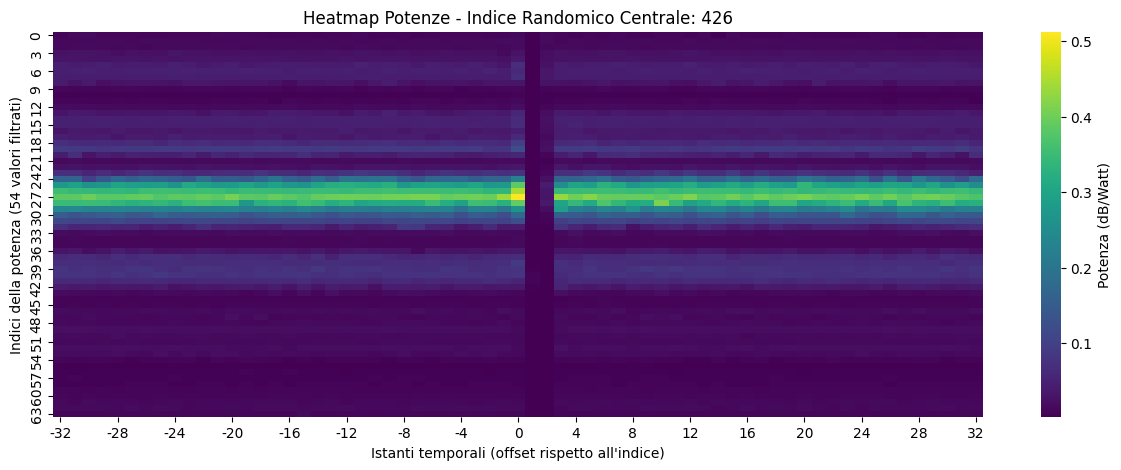

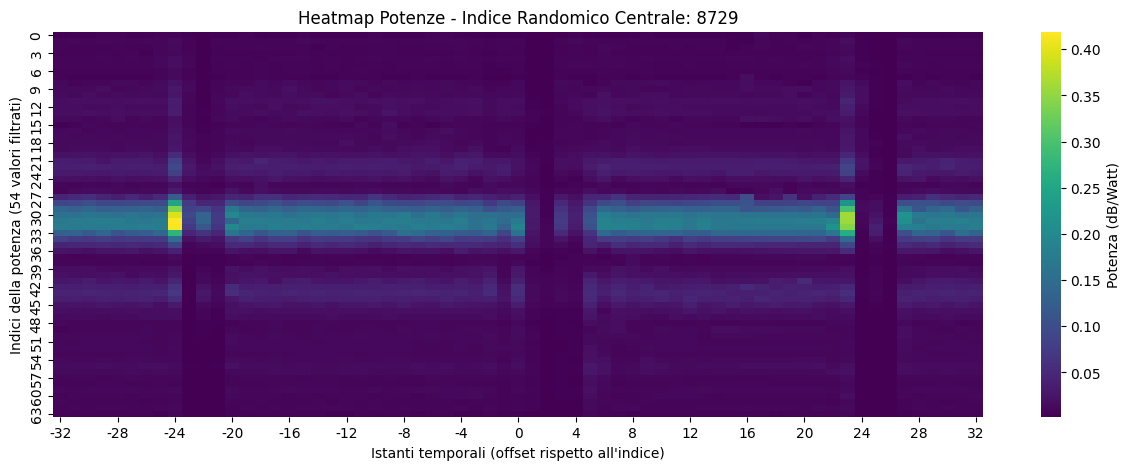

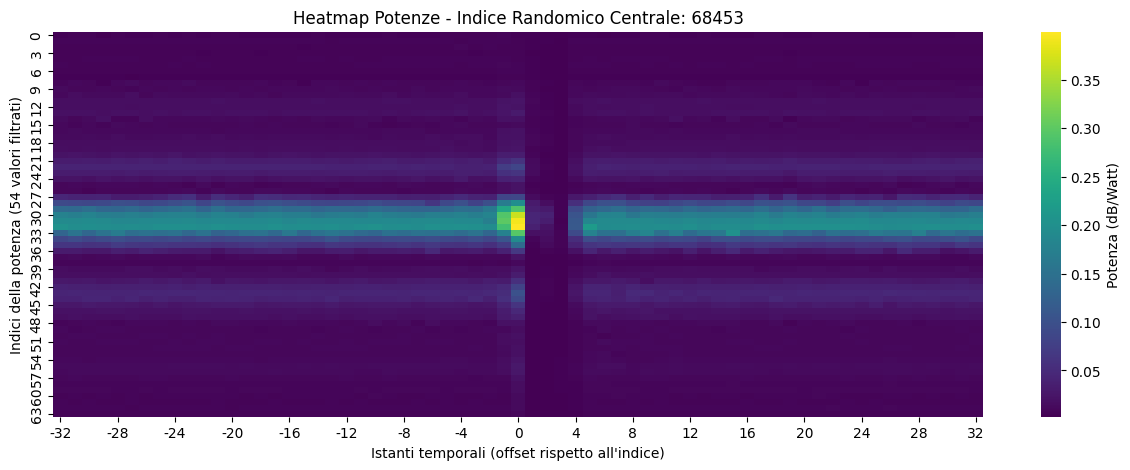

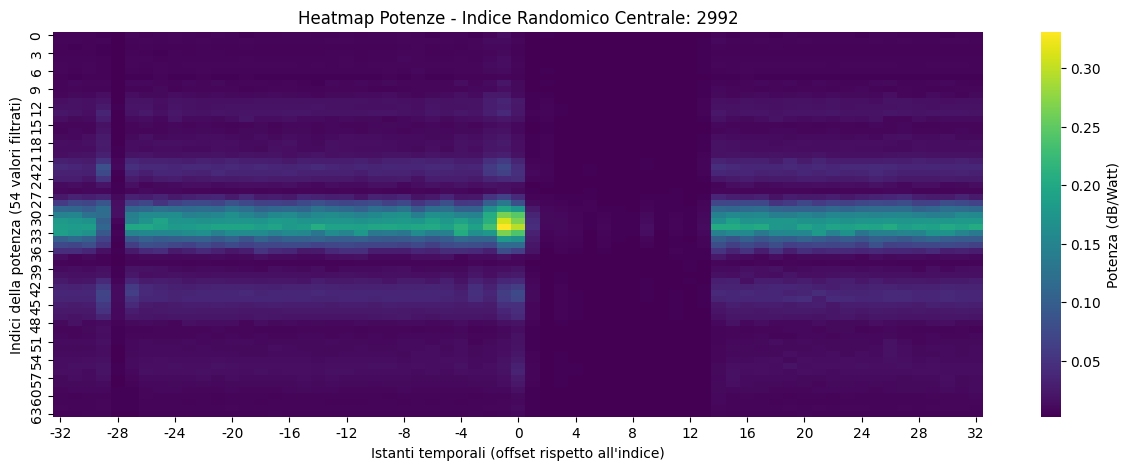

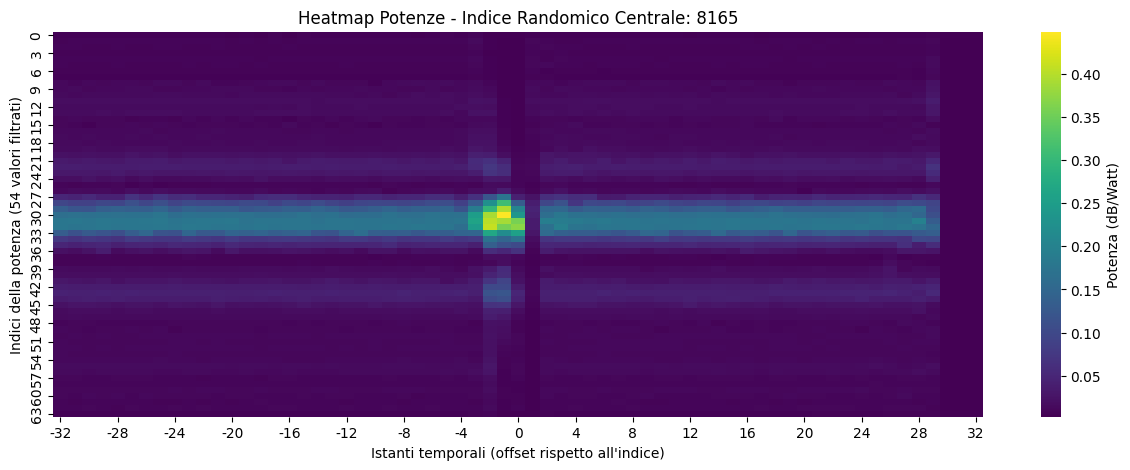

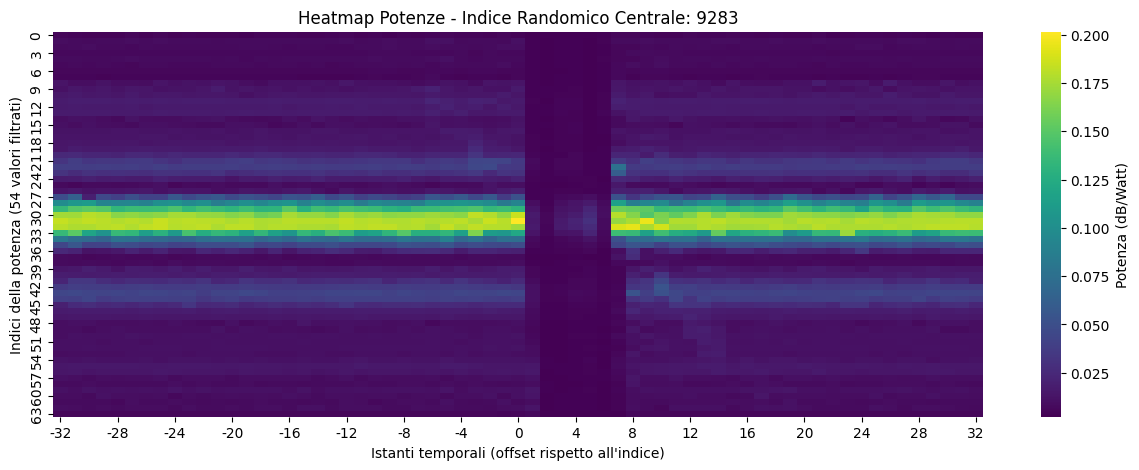

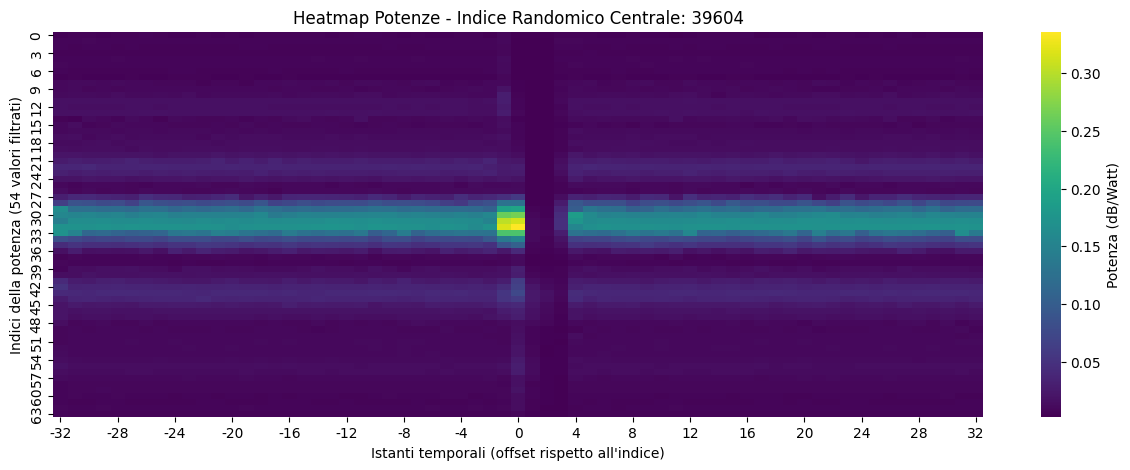

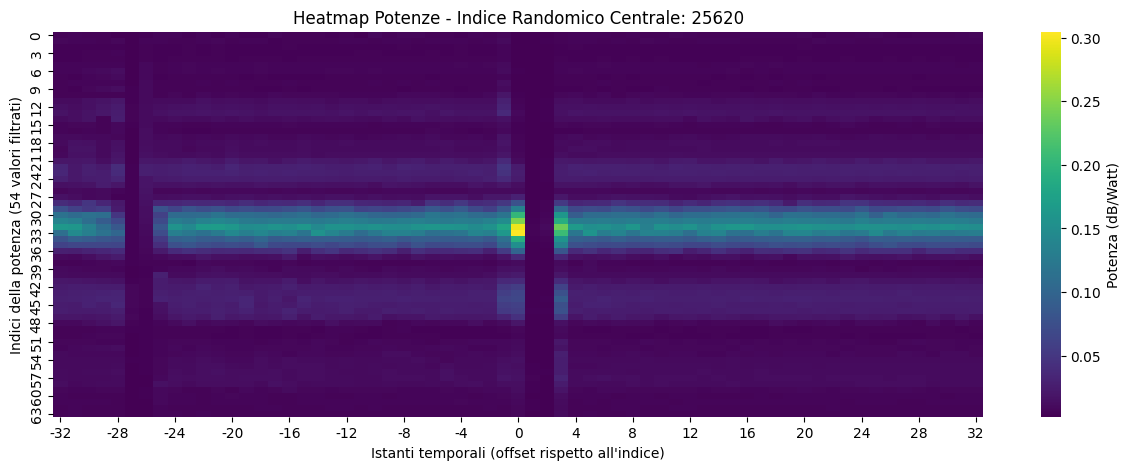

Analisi completata!


In [4]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_indici = './scenarios17_21_clean_neg_samples/scenario17_pos_indices.txt'
with open(file_indici, 'r') as f:
    indices = [int(line.strip()) for line in f if line.strip()]

random.seed(1234)
random_indices = random.sample(indices, 10)

base_path = "./scenario17/unit1/mmWave_data"

for idx in random_indices:
    heatmap_data = []
    time_steps_labels = []
    
    for t in range(-32, 33):
        k = idx + t
        mmWave_file_path = os.path.join(base_path, f"mmWave_power_{k}.txt")
        
        power_cut = [np.nan] * 54 
        
        try:
            with open(mmWave_file_path, "r") as file:
                power_cut = [float(line) for line in file.read().splitlines()]
                
                # if len(power_floats) >= 64:
                #     power_cut = power_floats[:27] + power_floats[37:]
        except FileNotFoundError:
            pass
        
        heatmap_data.append(power_cut)
        time_steps_labels.append(t)
        
    heatmap_matrix = np.array(heatmap_data).T 
    
    df_heatmap = pd.DataFrame(heatmap_matrix, columns=time_steps_labels)
    
    plt.figure(figsize=(15, 5))
    
    sns.heatmap(df_heatmap, cmap="viridis", cbar_kws={'label': 'Potenza (dB/Watt)'})
    
    plt.title(f"Heatmap Potenze - Indice Randomico Centrale: {idx}")
    plt.xlabel("Istanti temporali (offset rispetto all'indice)")
    plt.ylabel("Indici della potenza (54 valori filtrati)")
    
    ticks_positions = np.arange(0, 65, 4) + 0.5
    ticks_labels = np.arange(-32, 33, 4)
    plt.xticks(ticks_positions, ticks_labels, rotation=0)   # type: ignore
    plt.show()

print("Analisi completata!")

The following cell lets you visualize a user-specified sample (heatmap) for all Tps, to clearly see if the sliding window worked properly.
The sample can be both positive or negative.

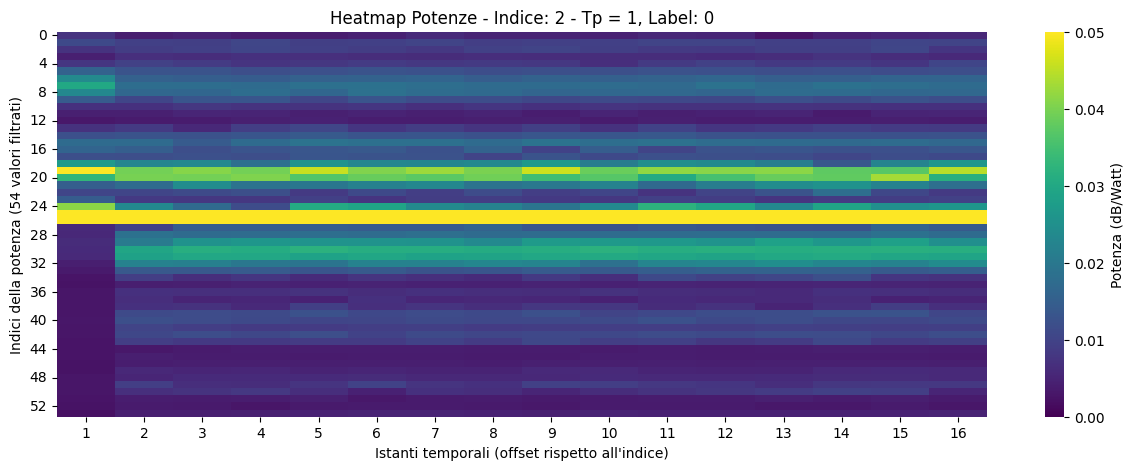

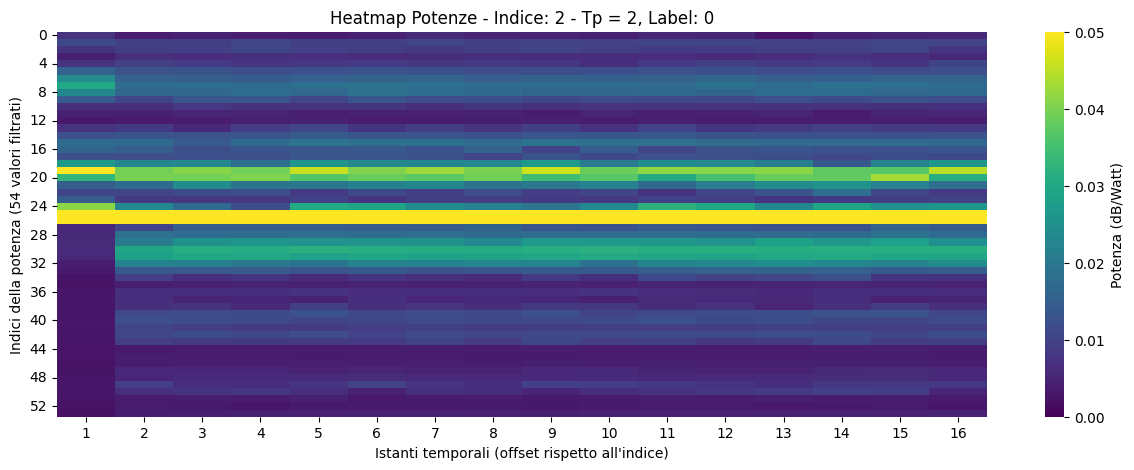

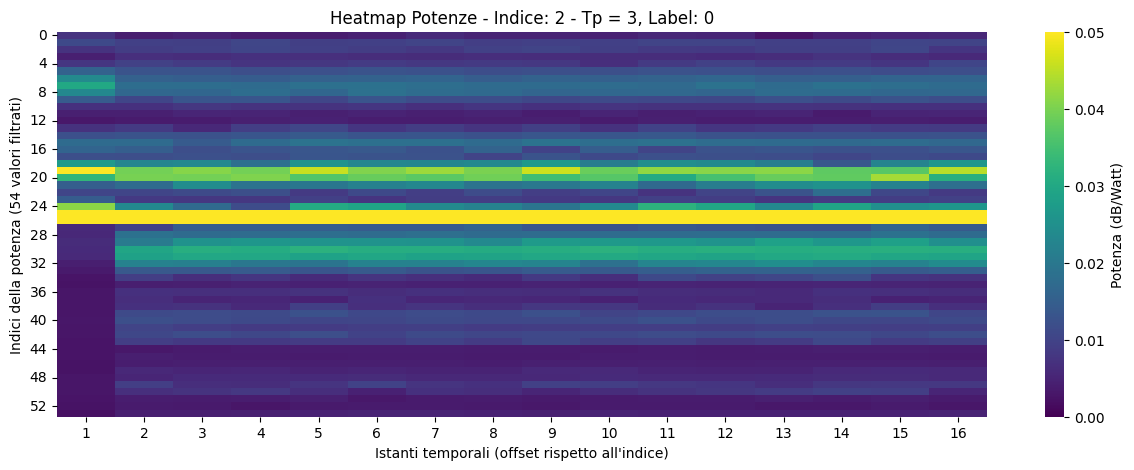

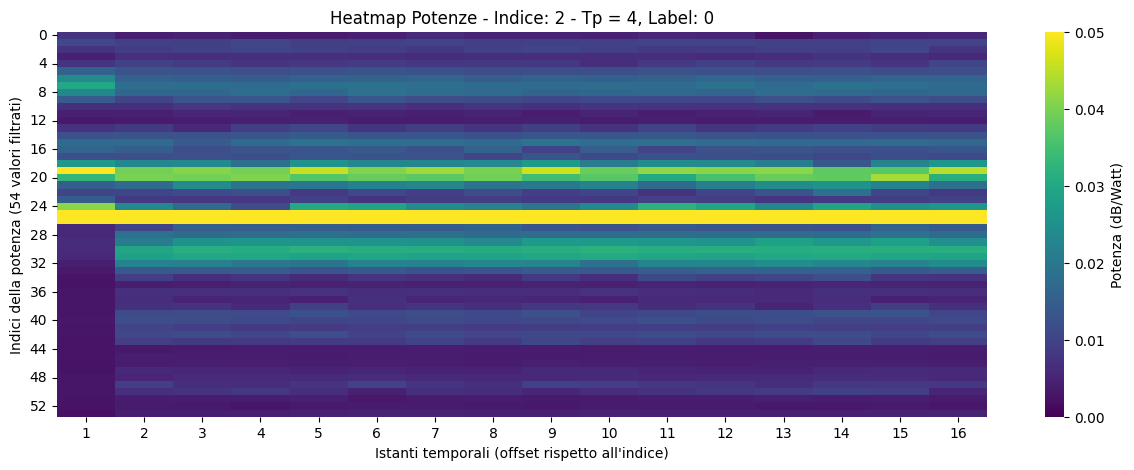

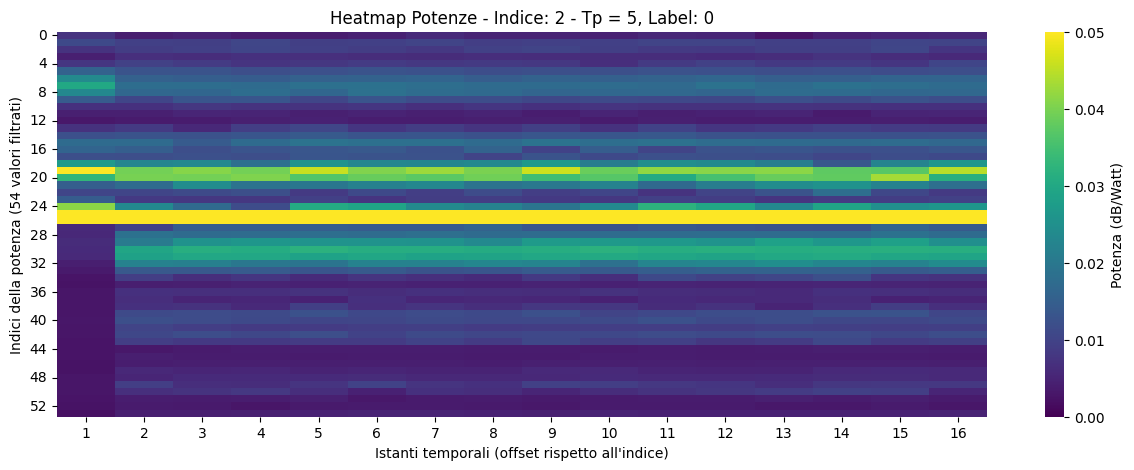

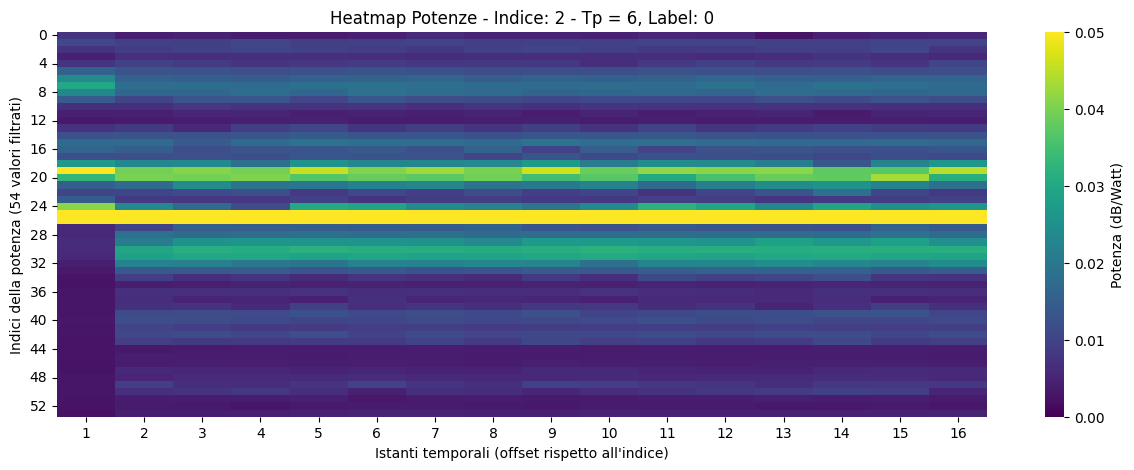

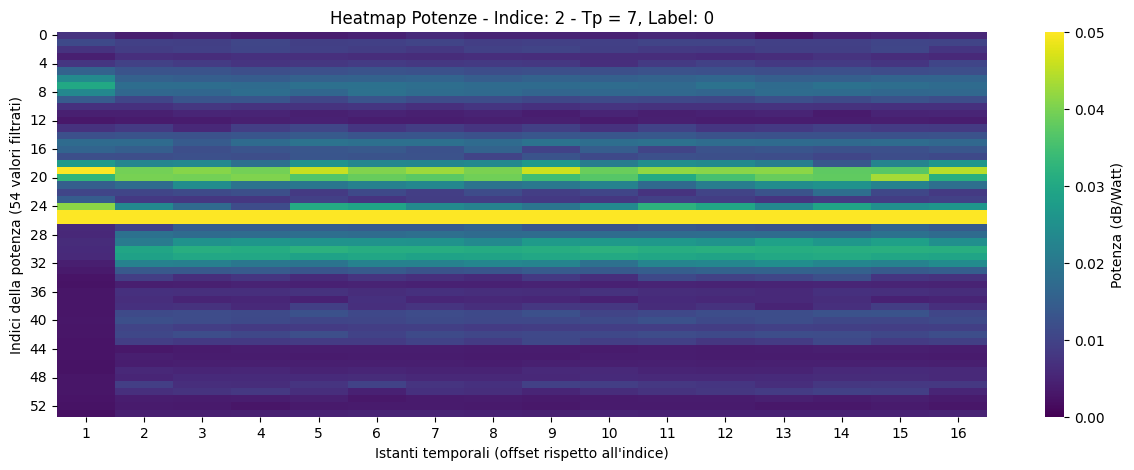

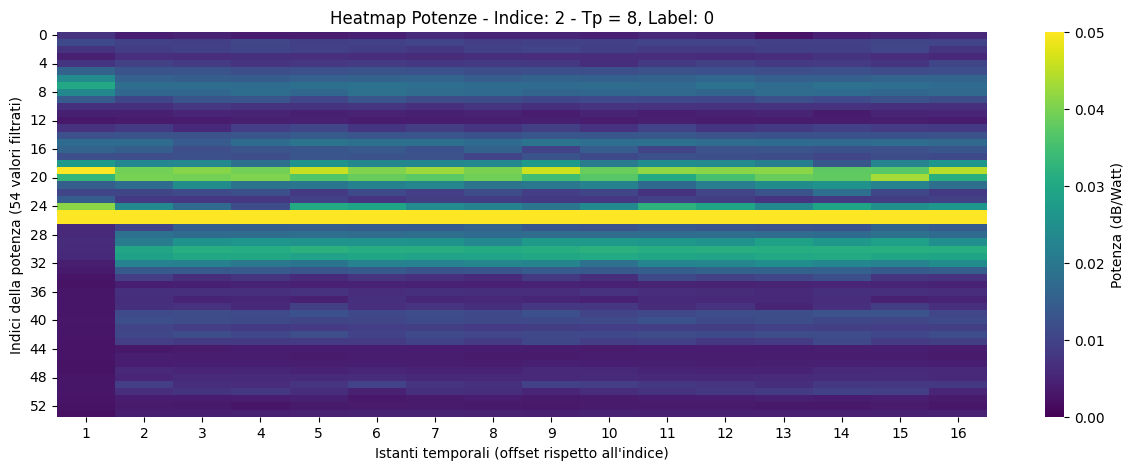

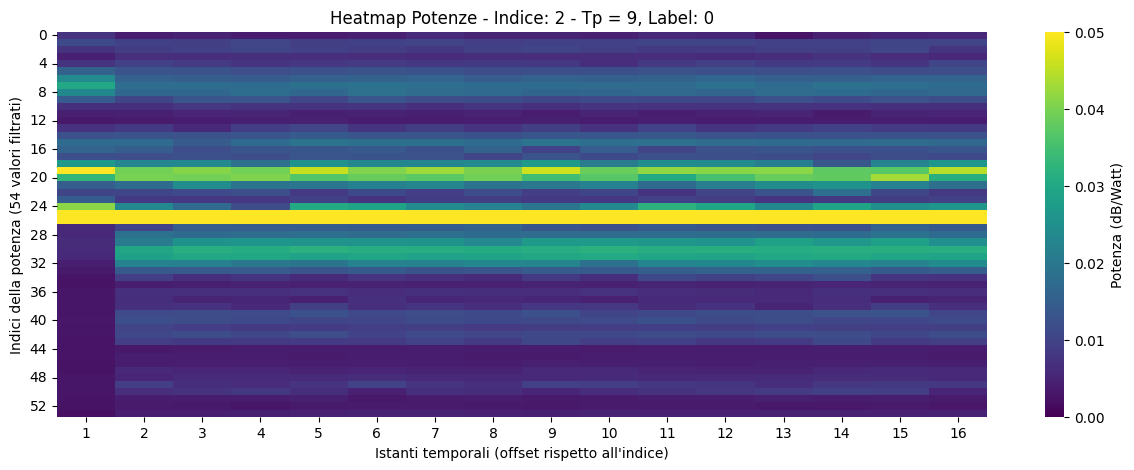

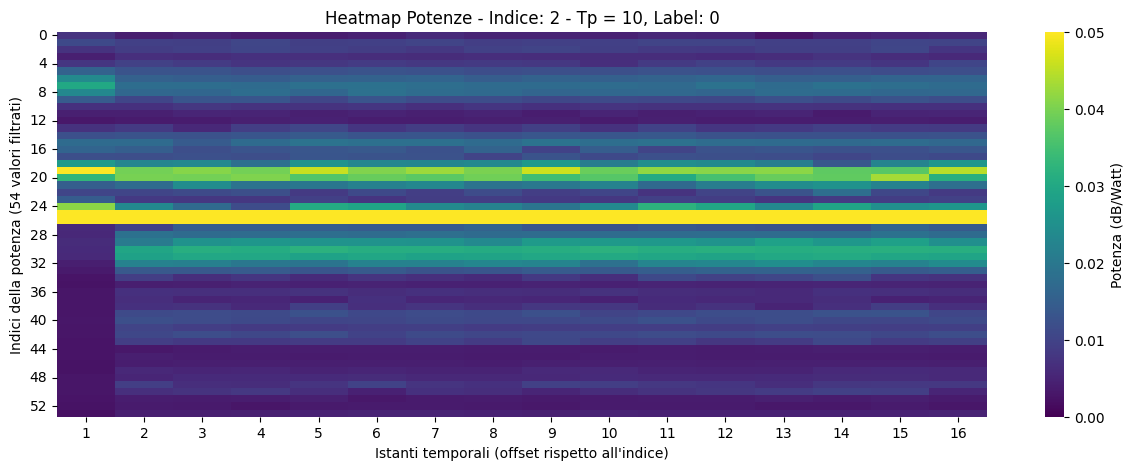

Analisi completata!


In [4]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

random.seed(1234)
random_index = [2]  # user-specified sample that will be visualized

tps = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
random_heatmap = {tp: None for tp in tps}
random_labels = {tp: None for tp in tps}
for tp in tps:
    file_path = f'./scenarios17_21_clean_neg_samples/train/train_Tp{tp}.npz'
    data = np.load(file_path)
    random_heatmap[tp] = data['features'][random_index]
    random_labels[tp] = data['labels'][random_index]

for tp in tps:
    tp_heatmap = random_heatmap[tp]
    heatmap_matrix = np.array(tp_heatmap).T
    heatmap_matrix = heatmap_matrix[:, :, 0]
    
    df_heatmap = pd.DataFrame(heatmap_matrix, columns=np.arange(1, 17))
    
    plt.figure(figsize=(15, 5))
    
    sns.heatmap(df_heatmap, cmap="viridis", vmin=0, vmax=0.05, cbar_kws={'label': 'Potenza (dB/Watt)'})
    
    plt.title(f"Heatmap Potenze - Indice: {random_index[0]} - Tp = {tp}, Label: {random_labels[tp][0]}")    # type: ignore
    plt.xlabel("Istanti temporali (offset rispetto all'indice)")
    plt.ylabel("Indici della potenza (54 valori filtrati)")
    
    plt.xticks(np.arange(0, 16) + 0.5, [str(x) for x in np.arange(1, 17)], rotation=0)
    plt.yticks(np.arange(0, 54, 4) + 0.5, [str(x) for x in np.arange(0, 54, 4)], rotation=0)
    
    plt.show()

print("Analisi completata!")